# Made by

## Name      : Anthony Djiady Djie
## Class     : Dibimbing DS39+
## Topic     : Final Project DS (K-means Clustering)
## Linkedin  : www.linkedin.com/in/anthony-djiady-djie




#

# SECTION 1: Data Collection

## 1.1 Dataset Background

* It contains transaction data from a UK-based online retailer, covering a period from December 2009 to December 2011.

## 1.2 Import Library

In [ ]:
# ================================
# Libraries for EDA, RFM & K-Means
# ================================

# Core data handling
import pandas as pd
import numpy as np

# Data visualization (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Feature scaling
from sklearn.preprocessing import StandardScaler

# K-Means clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Dimensionality reduction (for cluster visualization)
from sklearn.decomposition import PCA

# Utility
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


In [ ]:
# Load dataset (moved from cell NGTrY3UEqgYY to ensure df is defined)
df = pd.read_csv(
    '/content/online_retail_cleaned.csv')
print('Dataset loaded successfully!')

# Convert dataset to parquet
# The 'df' dataframe is already loaded from 'online_retail_cleaned.csv' in a previous cell.
# The file 'online_retail_cleaned.xlsx' caused a BadZipFile error, suggesting it's not a valid Excel file.
# Therefore, we will proceed with the 'df' already in memory from the CSV load.

# convert to parquet
df.to_parquet("online_retail_cleaned.parquet", engine="pyarrow")

print("Conversion complete!")

Dataset loaded successfully!
Conversion complete!


## 1.3 Load dataset


In [ ]:
# Load dataset
df = pd.read_csv(
    '/content/online_retail_cleaned.csv')
print('Dataset loaded successfully!')

Dataset loaded successfully!


In [ ]:
df.columns

Index(['invoice', 'stockcode', 'description', 'quantity', 'invoicedate',
       'price', 'customer_id', 'country', 'is_cancelled', 'total_price'],
      dtype='object')

## 1.4 Data Info

In [ ]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062989 entries, 0 to 1062988
Data columns (total 10 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   invoice       1062989 non-null  object 
 1   stockcode     1062989 non-null  object 
 2   description   1062989 non-null  object 
 3   quantity      1062989 non-null  int64  
 4   invoicedate   1062989 non-null  object 
 5   price         1062989 non-null  float64
 6   customer_id   824364 non-null   float64
 7   country       1062989 non-null  object 
 8   is_cancelled  1062989 non-null  bool   
 9   total_price   1062989 non-null  float64
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 74.0+ MB


## 1.5 Data Attributes

| Attribute Name | Data Type            | Description                                                                                     |
| -------------- | -------------------- | ----------------------------------------------------------------------------------------------- |
| `invoice`   | Categorical (String) | Unique invoice identifier for each transaction. A single invoice may contain multiple products. |
| `stock_code`   | Categorical (String) | Unique code identifying each product item.                                                      |
| `description`  | Text                 | Name or description of the purchased product.                                                   |
| `quantity`     | Numerical (Integer)  | Number of units purchased per product in a transaction.                                         |
| `invoicedate`  | DateTime             | Date and time when the transaction occurred.                                                    |
| `price`        | Numerical (Float)    | Unit price of the product at the time of purchase.                                              |
| `customer_id`  | Categorical (String) | Unique identifier for each customer. Used as the main key for customer segmentation.            |
| `country`      | Categorical (String) | Country where the customer is located.
| `is_cancelled` | Boolean           | Indicates whether a transaction is cancelled or returned (`True` for cancelled, `False` otherwise).  |
| `total_price`  | Numerical (Float) | Total monetary value of a transaction, calculated as `quantity × price`. Used for monetary analysis. |
                

## 1.6 Goals and Objective of the Data Analysis
Project Goal

Online retail businesses generate large amounts of transaction data, but often struggle to understand differences in customer purchasing behavior, leading to inefficient marketing strategies, poor customer retention, and missed opportunities to maximize revenue. Without identifying which customers are loyal, high-value, or at risk of becoming inactive, companies may treat all customers the same and fail to allocate resources effectively. To address this problem, this project applies customer segmentation using Recency, Frequency, and Monetary (RFM) analysis combined with K-Means clustering to group customers based on their purchasing patterns. By identifying customers with similar behavior in terms of how recently they purchase, how often they buy, and how much they spend, K-Means clustering helps the business better understand customer characteristics, enable targeted marketing strategies, improve retention efforts, and support data-driven decision-making to enhance overall business performance.

#

# SECTION 2: Data Understanding/Data Cleaning

## 2.1 Basic data inspection


In [ ]:
# Print Data Dimension
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

# Data types & nulls
print('Data Types:')
print(df.info())

# Data Summary
print('Data Summary')
print(df.describe())

# Unique counts per column
print(df.nunique())

Dataset shape: 1062989 rows × 10 columns

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062989 entries, 0 to 1062988
Data columns (total 10 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   invoice       1062989 non-null  object 
 1   stockcode     1062989 non-null  object 
 2   description   1062989 non-null  object 
 3   quantity      1062989 non-null  int64  
 4   invoicedate   1062989 non-null  object 
 5   price         1062989 non-null  float64
 6   customer_id   824364 non-null   float64
 7   country       1062989 non-null  object 
 8   is_cancelled  1062989 non-null  bool   
 9   total_price   1062989 non-null  float64
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 74.0+ MB
None
Data Summary
           quantity         price    customer_id   total_price
count  1.062989e+06  1.062989e+06  824364.000000  1.062989e+06
mean   1.005103e+01  4.668554e+00   15324.638504  1.814436e+01
std    1.69930

### Observation:
- The 'customer_id' should be 'str' type
- The 'invoicedate' should be 'datetime' format
- There seems to be null values in the 'customer_id' column
- We don't really need much feature engineering as the 'total_price' already existed

## 2.2 Convert the columns to their appropriate data types.

In [ ]:
# Drop missing customer first
df = df.dropna(subset=['customer_id'])

In [ ]:
# Converting 'customer_id' to object format
df['customer_id'] = df['customer_id'].astype(str)

In [ ]:
# Converting 'invoicedate' to datetime format
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

In [ ]:
# Checking if its already coverted
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824364 entries, 0 to 1062988
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice       824364 non-null  object        
 1   stockcode     824364 non-null  object        
 2   description   824364 non-null  object        
 3   quantity      824364 non-null  int64         
 4   invoicedate   824364 non-null  datetime64[ns]
 5   price         824364 non-null  float64       
 6   customer_id   824364 non-null  object        
 7   country       824364 non-null  object        
 8   is_cancelled  824364 non-null  bool          
 9   total_price   824364 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 63.7+ MB


## 2.3 Identify Column types


In [ ]:
# Identify column types
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print('Numerical Columns:', numerical_cols)
print('\nCategorical Columns:', categorical_cols)

Numerical Columns: ['quantity', 'price', 'total_price']

Categorical Columns: ['invoice', 'stockcode', 'description', 'customer_id', 'country']


## 2.4 Identify Null value



In [ ]:
# Identify if there is empty strings in all the categorical column
categorical_cols = df.select_dtypes(include='object').columns

# Check for empty strings in each string column
empty_string_counts = {}
for col in categorical_cols:
    is_empty_string = df[col].apply(lambda x: isinstance(x, str) and len(x) == 0)
    is_nan_string = df[col].astype(str).str.lower() == 'nan'
    empty_or_nan_string_count = (is_empty_string | is_nan_string).sum()
    empty_string_counts[col] = empty_or_nan_string_count

# Display the results
for col, count in empty_string_counts.items():
    if count > 0:
        print(f"Column '{col}' contains {count} empty strings.")
    else:
        print(f"Column '{col}' contains no empty strings.")

# Identify if there is empty value in all the numerical column
for col in numerical_cols:
    zero_count = (df[col] == 0).sum()
    negative_count = (df[col] < 0).sum()
    print(f"Column '{col}': {zero_count} zeros, {negative_count} negative values")

Column 'invoice' contains no empty strings.
Column 'stockcode' contains no empty strings.
Column 'description' contains no empty strings.
Column 'customer_id' contains no empty strings.
Column 'country' contains no empty strings.
Column 'quantity': 0 zeros, 18744 negative values
Column 'price': 71 zeros, 0 negative values
Column 'total_price': 71 zeros, 18744 negative values


### Dealing with Null Value

* We are getting rid of negative values and null values in Quantity and UnitPrice are invalid and likely due to data entry errors, so they should be removed

* We are also getting rid of null value on 'customerid' as it is very hard to track the customer (it could be a new customer or existing customer) it is very hard to identify which one is which

In [ ]:
# Drop null and negative values in price, quantity
df = df[(df['price'] > 0) & (df['quantity'] > 0)]

In [ ]:
# Drop null value in customerid
df['customer_id'] = df['customer_id'].replace('nan', np.nan)
df = df.dropna(subset=['customer_id'])

In [ ]:
# Lets recheck
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n")


# Check for empty strings in each string column
empty_string_counts = {}
for col in categorical_cols:
    is_empty_string = df[col].apply(lambda x: isinstance(x, str) and len(x) == 0)
    is_nan_string = df[col].astype(str).str.lower() == 'nan'
    empty_or_nan_string_count = (is_empty_string | is_nan_string).sum()
    empty_string_counts[col] = empty_or_nan_string_count

# Display the results
for col, count in empty_string_counts.items():
    if count > 0:
        print(f"Column '{col}' contains {count} empty strings.")
    else:
        print(f"Column '{col}' contains no empty strings.")

# Identify if there is empty value in all the numerical column
for col in numerical_cols:
    zero_count = (df[col] == 0).sum()
    negative_count = (df[col] < 0).sum()
    print(f"Column '{col}': {zero_count} zeros, {negative_count} negative values")

Dataset shape: 805549 rows × 10 columns

Column 'invoice' contains no empty strings.
Column 'stockcode' contains no empty strings.
Column 'description' contains no empty strings.
Column 'customer_id' contains no empty strings.
Column 'country' contains no empty strings.
Column 'quantity': 0 zeros, 0 negative values
Column 'price': 0 zeros, 0 negative values
Column 'total_price': 0 zeros, 0 negative values


## 2.5 Identify Unique Value

In [ ]:
# Unique Value for Categorical and Boolean
print('\nCategorical Variables Summary:')
for col in categorical_cols:
    print(f'{col}: {df[col].nunique()} unique values')
    print(f'  Values: {df[col].unique()}')


Categorical Variables Summary:
invoice: 36969 unique values
  Values: ['489434' '489435' '489436' ... '581585' '581586' '581587']
stockcode: 4631 unique values
  Values: ['85048' '79323P' '79323W' ... '23562' '23561' '23843']
description: 5283 unique values
  Values: ['15CM CHRISTMAS GLASS BALL 20 LIGHTS' 'PINK CHERRY LIGHTS'
 ' WHITE CHERRY LIGHTS' ... 'SILVER AND BLACK ORBIT NECKLACE'
 'CREAM HANGING HEART T-LIGHT HOLDER' 'PAPER CRAFT , LITTLE BIRDIE']
customer_id: 5878 unique values
  Values: ['13085.0' '13078.0' '15362.0' ... '15520.0' '13298.0' '12713.0']
country: 41 unique values
  Values: ['United Kingdom' 'France' 'USA' 'Belgium' 'Australia' 'EIRE' 'Germany'
 'Portugal' 'Denmark' 'Netherlands' 'Poland' 'Channel Islands' 'Spain'
 'Cyprus' 'Greece' 'Norway' 'Austria' 'Sweden' 'United Arab Emirates'
 'Finland' 'Italy' 'Switzerland' 'Japan' 'Unspecified' 'Nigeria' 'Malta'
 'RSA' 'Singapore' 'Bahrain' 'Thailand' 'Israel' 'Lithuania' 'West Indies'
 'Korea' 'Brazil' 'Canada' 'Iceland

## 2.6 Identify Duplicate

In [ ]:
# Check Duplicate as a whole
df.duplicated().sum()

np.int64(26124)

In [ ]:
# Check the Row with duplicate
df[df.duplicated(keep=False)]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,total_price
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,False,3.75
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,False,3.75
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,False,3.75
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom,False,7.80
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom,False,5.10
...,...,...,...,...,...,...,...,...,...,...
1062754,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom,False,0.39
1062768,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom,False,2.49
1062771,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom,False,1.95
1062778,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom,False,2.10


### Dealing with Duplicates
* As we can see from the output above, the duplicates are consist of the same invoice but different items. This shows that the duplicates is caused by a person buying different items in a single purchase, thus the same invoice but different stockcode

* Therefore, we are not going to get rid of the duplicates



#


# SECTION 3: EDA

## 3.1 Distribution Analysis

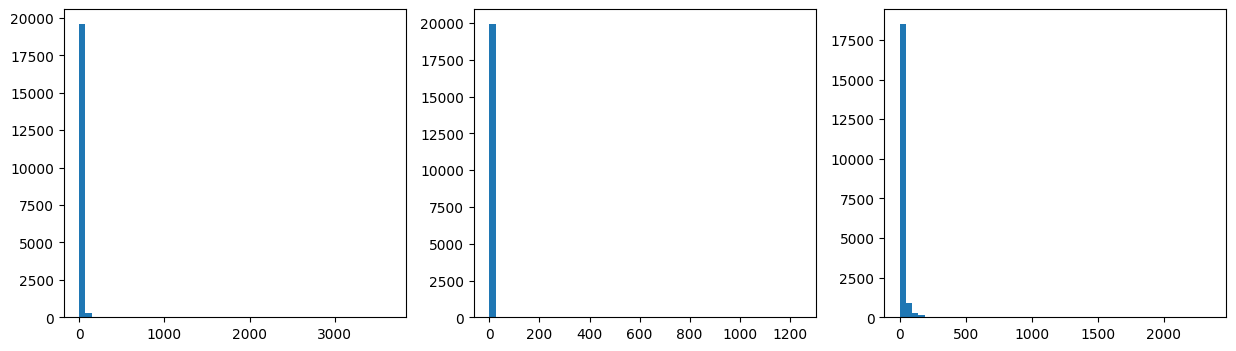

In [ ]:
# Distribution of RFM related variables
sample_df = df.sample(20000)

fig, ax = plt.subplots(1,3,figsize=(15,4))

ax[0].hist(sample_df['quantity'], bins=50)
ax[1].hist(sample_df['price'], bins=50)
ax[2].hist(sample_df['total_price'], bins=50)

plt.show()

## 3.2 Correlation Analysis

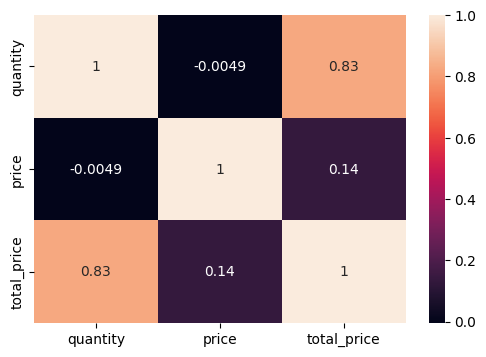

In [ ]:
# Correlation Analysis
plt.figure(figsize=(6,4))
sns.heatmap(df[['quantity','price','total_price']].corr(), annot=True)
plt.show()

## 3.3 Finding outliers

In [ ]:
# Identify outliers from all the numerical category
# === Outlier detection using IQR method ===
outlier_summary = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'LowerBound': lower_bound,
        'UpperBound': upper_bound,
        'OutlierCount': len(outliers),
        'OutlierPercentage': len(outliers) / len(df) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
outlier_df

,Q1,Q3,IQR,LowerBound,UpperBound,OutlierCount,OutlierPercentage
quantity,2.00,12.00,10.00,-13.000,27.000,51983.0,6.453115
price,1.25,3.75,2.50,-2.500,7.500,67346.0,8.360261
total_price,4.95,19.50,14.55,-16.875,41.325,66382.0,8.240591


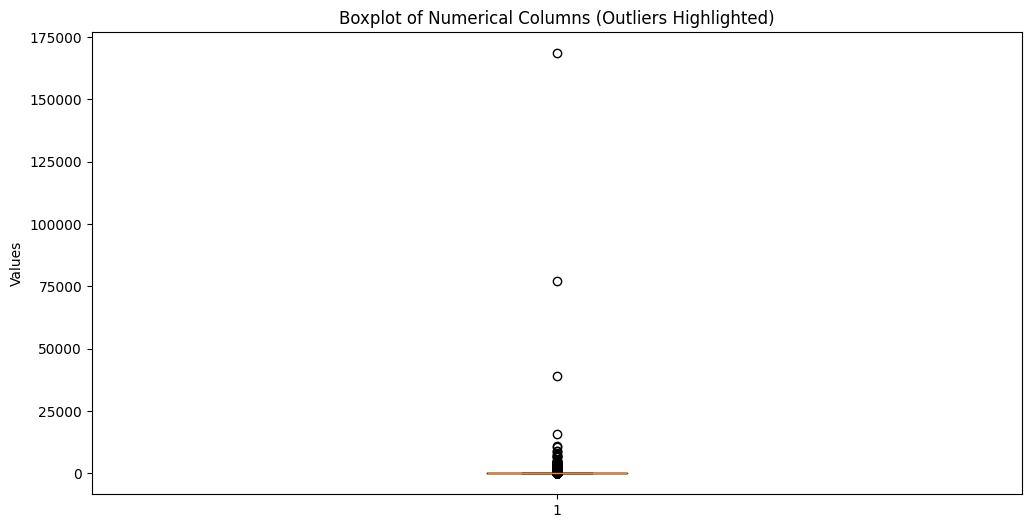

In [ ]:
# Visualisation
plt.figure(figsize=(12,6))
plt.boxplot(df['total_price'])
plt.title("Boxplot of Numerical Columns (Outliers Highlighted)")
plt.ylabel("Values")
plt.show()

In [ ]:
# Checking final df
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1062988
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice       805549 non-null  object        
 1   stockcode     805549 non-null  object        
 2   description   805549 non-null  object        
 3   quantity      805549 non-null  int64         
 4   invoicedate   805549 non-null  datetime64[ns]
 5   price         805549 non-null  float64       
 6   customer_id   805549 non-null  object        
 7   country       805549 non-null  object        
 8   is_cancelled  805549 non-null  bool          
 9   total_price   805549 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 62.2+ MB


### Dealing with outliers

#### We will not be removing any outliers, due to the fact that these outliers are actually customers who spends extreme amount. Therefore, we are not going to remove it because it is an important data that we can use and leverage from it.

#

# SECTION 4: Feature Engineering

## 4.1 Define date for Recency

In [ ]:
# Usually we take max date + 1 day
snapshot_date = df['invoicedate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

## 4.2 Aggregate Core Metrics

In [ ]:
rfm = df.groupby('customer_id').agg({
    'invoicedate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'invoice': 'nunique',                                     # Frequency
    'total_price': 'sum',                                     # Monetary (Total Spending)
    'quantity': 'sum'                                         # Total Quantity
}).reset_index()

rfm.columns = [
    'customer_id',
    'Recency',
    'Frequency',
    'Monetary',
    'Total_Quantity'
]

rfm.head()


,customer_id,Recency,Frequency,Monetary,Total_Quantity
0,12346.0,326,12,77556.46,74285
1,12347.0,2,8,5633.32,3286
2,12348.0,75,5,2019.40,2714
3,12349.0,19,4,4428.69,1624
4,12350.0,310,1,334.40,197


## 4.3 Calculate Average Order Value (AOV)

In [ ]:
# Average Order Value
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']

## 4.4 Calculate Average Quantity per Invoice

In [ ]:
# Averaga Quantity per Invoice
rfm['Avg_Quantity_per_Invoice'] = rfm['Total_Quantity'] / rfm['Frequency']

## 4.5 Final Feature Table

In [ ]:
# Final Table
features = rfm.drop(['customer_id', 'Total_Quantity'], axis=1)

features.head()

,Recency,Frequency,Monetary,AOV,Avg_Quantity_per_Invoice
0,326,12,77556.46,6463.038333,6190.416667
1,2,8,5633.32,704.165000,410.750000
2,75,5,2019.40,403.880000,542.800000
3,19,4,4428.69,1107.172500,406.000000
4,310,1,334.40,334.400000,197.000000


## 4.6 Log Transformation to prevent Skewedness

In [ ]:
# Copy from your RFM dataframe
filtered_log = rfm.copy()

cols_to_log = ['Recency', 'Frequency', 'Monetary', 'AOV', 'Avg_Quantity_per_Invoice']

filtered_log[cols_to_log] = np.log1p(filtered_log[cols_to_log])

filtered_log.head()

,customer_id,Recency,Frequency,Monetary,Total_Quantity,AOV,Avg_Quantity_per_Invoice
0,12346.0,5.789960,2.564949,11.258774,74285,8.774010,8.730919
1,12347.0,1.098612,2.197225,8.636632,3286,6.558432,6.020416
2,12348.0,4.330733,1.791759,7.611051,2714,6.003591,6.298582
3,12349.0,2.995732,1.609438,8.396085,1624,7.010468,6.008813
4,12350.0,5.739793,0.693147,5.815324,197,5.815324,5.288267


#

# SECTION 5: K-Means Clustering

## 5.1 Feature Scaling

In [ ]:
# Standard Scaler
# Only use the 5 intended features for clustering
features_to_scale = filtered_log[
    ['Recency', 'Frequency', 'Monetary', 'AOV', 'Avg_Quantity_per_Invoice']
]

scaler = StandardScaler()
filtered_scaled = scaler.fit_transform(features_to_scale)

## 5.2 Find Optimal Cluster

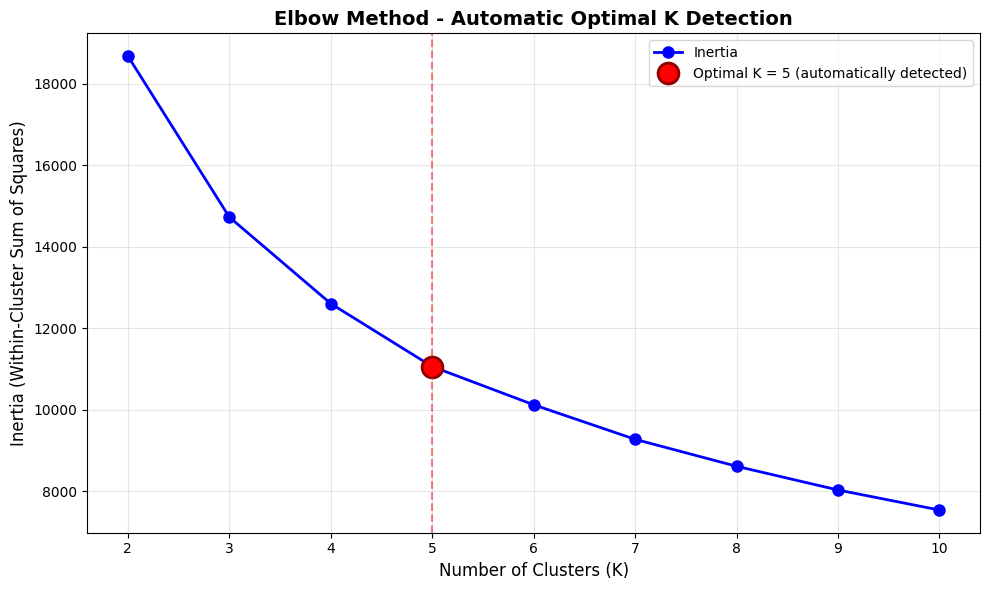


📊 ELBOW METHOD RESULTS
✅ Automatically detected optimal K = 5
📈 Inertia at K=5: 11060.23


In [ ]:
# Elbow Method
# Calculate inertia for different K values
inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(filtered_scaled)
    inertia.append(kmeans.inertia_)

# Calculate the elbow point using the "knee method"
# Find the point of maximum curvature
def find_elbow_point(k_values, inertia):
    # Convert to numpy arrays
    k = np.array(list(k_values))
    inert = np.array(inertia)

    # Normalize values to [0,1] range
    k_norm = (k - k.min()) / (k.max() - k.min())
    inert_norm = (inert - inert.min()) / (inert.max() - inert.min())

    # Calculate distances from line connecting first and last points
    # Line from first point to last point
    line_vec = np.array([k_norm[-1] - k_norm[0], inert_norm[-1] - inert_norm[0]])
    line_len = np.linalg.norm(line_vec)

    if line_len == 0:
        return k_values[len(k_values)//2]  # fallback to middle if line has zero length

    line_unit = line_vec / line_len

    distances = []
    for i in range(len(k_norm)):
        # Vector from first point to current point
        point_vec = np.array([k_norm[i] - k_norm[0], inert_norm[i] - inert_norm[0]])

        # Project point_vec onto line_unit
        proj_len = np.dot(point_vec, line_unit)
        proj_vec = proj_len * line_unit

        # Vector from projected point to actual point
        dist_vec = point_vec - proj_vec
        dist = np.linalg.norm(dist_vec)
        distances.append(dist)

    # Elbow is at maximum distance (point farthest from the line)
    elbow_idx = np.argmax(distances)
    return k_values[elbow_idx]

# Find optimal K automatically
optimal_k = find_elbow_point(list(k_values), inertia)
optimal_index = optimal_k - 2  # because range starts at 2

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, 'bo-', linewidth=2, markersize=8, label='Inertia')

# Mark the automatically detected optimal K with a red dot
plt.plot(optimal_k, inertia[optimal_index], 'ro', markersize=15, markeredgewidth=2,
         markeredgecolor='darkred', label=f'Optimal K = {optimal_k} (automatically detected)')

# Add vertical line at optimal K
plt.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.5)

# Add labels and title
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=12)
plt.title("Elbow Method - Automatic Optimal K Detection", fontsize=14, fontweight='bold')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Add legend
plt.legend(loc='best')

plt.tight_layout()
plt.show()

print(f"\n📊 ELBOW METHOD RESULTS")
print("=" * 40)
print(f"✅ Automatically detected optimal K = {optimal_k}")
print(f"📈 Inertia at K={optimal_k}: {inertia[optimal_index]:.2f}")

K=2, Silhouette Score=0.3204
K=3, Silhouette Score=0.2671
K=4, Silhouette Score=0.2560
K=5, Silhouette Score=0.2426
K=6, Silhouette Score=0.2386
K=7, Silhouette Score=0.2350
K=8, Silhouette Score=0.2327
K=9, Silhouette Score=0.2368
K=10, Silhouette Score=0.2374


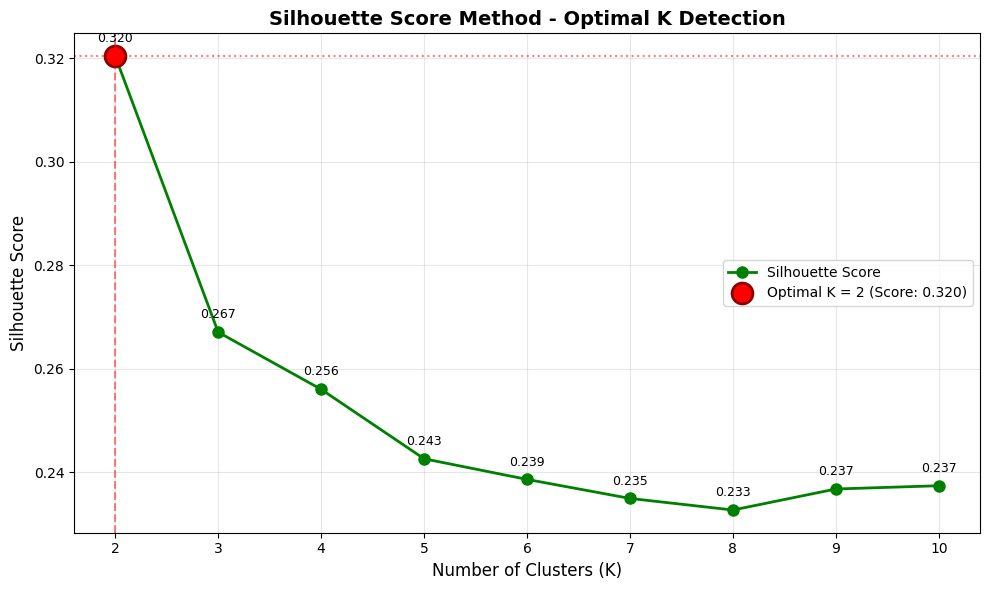


📊 SILHOUETTE SCORE ANALYSIS
✅ Optimal K = 2
📈 Best Silhouette Score = 0.3204
📊 All scores: {2: np.float64(0.3204), 3: np.float64(0.2671), 4: np.float64(0.256), 5: np.float64(0.2426), 6: np.float64(0.2386), 7: np.float64(0.235), 8: np.float64(0.2327), 9: np.float64(0.2368), 10: np.float64(0.2374)}

🟡 Interpretation: Reasonable cluster separation


In [ ]:
# =====================================
# SILHOUETTE SCORE WITH AUTOMATIC OPTIMAL K DETECTION
# =====================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for different K values
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(filtered_scaled)
    score = silhouette_score(filtered_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

# Find optimal K (maximum silhouette score)
optimal_k = k_values[np.argmax(silhouette_scores)]
optimal_index = np.argmax(silhouette_scores)
optimal_score = silhouette_scores[optimal_index]

# Plot the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, 'go-', linewidth=2, markersize=8, label='Silhouette Score')

# Mark the optimal K with a red dot
plt.plot(optimal_k, optimal_score, 'ro', markersize=15, markeredgewidth=2,
         markeredgecolor='darkred', label=f'Optimal K = {optimal_k} (Score: {optimal_score:.3f})')

# Add vertical line at optimal K
plt.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.5)

# Add horizontal line at optimal score
plt.axhline(y=optimal_score, color='red', linestyle=':', alpha=0.5)

# Add labels and title
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Silhouette Score Method - Optimal K Detection", fontsize=14, fontweight='bold')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Add legend
plt.legend(loc='best')

# Add value labels on each point
for i, (k, score) in enumerate(zip(k_values, silhouette_scores)):
    plt.annotate(f'{score:.3f}', (k, score), textcoords="offset points",
                 xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 SILHOUETTE SCORE ANALYSIS")
print("=" * 50)
print(f"✅ Optimal K = {optimal_k}")
print(f"📈 Best Silhouette Score = {optimal_score:.4f}")
print(f"📊 All scores: {dict(zip(k_values, [round(s,4) for s in silhouette_scores]))}")

# Interpretation
if optimal_score > 0.5:
    print("\n🟢 Interpretation: Good cluster separation")
elif optimal_score > 0.3:
    print("\n🟡 Interpretation: Reasonable cluster separation")
else:
    print("\n🔴 Interpretation: Poor cluster separation")

In [ ]:
# Silhouette Score
silhouette_scores = []
n_clusters_range = range(2, 11)

for k in n_clusters_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(filtered_scaled)
    score = silhouette_score(filtered_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}, silhouette={score}")

trial_clust = pd.DataFrame({
    'n_cluster': list(n_clusters_range),
    'silhouette_score': silhouette_scores
})

# Assuming k=4 is the optimal cluster chosen based on prior observation
p_1 = trial_clust[trial_clust['n_cluster'] == 4]

k=2, silhouette=0.32041286950505943
k=3, silhouette=0.2670752415442709
k=4, silhouette=0.2560253005026408
k=5, silhouette=0.24261139757577532
k=6, silhouette=0.23862432564583455
k=7, silhouette=0.23495008154210392
k=8, silhouette=0.23270868051929394
k=9, silhouette=0.23677195899038214
k=10, silhouette=0.23740154715949102


###### Observation:
Although the silhouette score peaks at k = 2, this solution results in overly broad customer groups and lacks meaningful behavioral segmentation. The elbow method indicates diminishing improvements after k = 4–5, suggesting that additional clusters beyond this point provide limited explanatory power. Considering both statistical evaluation and business interpretability, k = 4 was selected as the final model because it provides a balanced segmentation that captures distinct customer behaviors while maintaining practical usability for marketing strategies.

In [ ]:
# Final Model
filtered = filtered_log.copy()

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
filtered['Cluster'] = kmeans.fit_predict(filtered_scaled)

filtered.head()

,customer_id,Recency,Frequency,Monetary,Total_Quantity,AOV,Avg_Quantity_per_Invoice,Cluster
0,12346.0,5.789960,2.564949,11.258774,74285,8.774010,8.730919,1
1,12347.0,1.098612,2.197225,8.636632,3286,6.558432,6.020416,1
2,12348.0,4.330733,1.791759,7.611051,2714,6.003591,6.298582,0
3,12349.0,2.995732,1.609438,8.396085,1624,7.010468,6.008813,1
4,12350.0,5.739793,0.693147,5.815324,197,5.815324,5.288267,0


#

# SECTION 6: Clustering Profiling and Analysis

## 6.1 Cluster Profiling

In [ ]:
# Cluster Profiling (CORRECT: use original units, not log values)

# Map cluster labels to customer_id safely
cluster_map = filtered[['customer_id', 'Cluster']].copy()

# Use ORIGINAL (non-log) RFM values for profiling
profile_df = rfm[['customer_id', 'Recency', 'Frequency', 'Monetary', 'AOV', 'Avg_Quantity_per_Invoice']].merge(
    cluster_map, on='customer_id', how='inner'
)

# Use median (more robust) + mean (optional)
cluster_profile = profile_df.groupby('Cluster').agg(
    Recency_median=('Recency', 'median'),
    Frequency_median=('Frequency', 'median'),
    Monetary_median=('Monetary', 'median'),
    AOV_median=('AOV', 'median'),
    AvgQtyPerInvoice_median=('Avg_Quantity_per_Invoice', 'median'),

    Recency_mean=('Recency', 'mean'),
    Frequency_mean=('Frequency', 'mean'),
    Monetary_mean=('Monetary', 'mean'),
    AOV_mean=('AOV', 'mean'),
    AvgQtyPerInvoice_mean=('Avg_Quantity_per_Invoice', 'mean'),

    Customer_Count=('customer_id', 'nunique')
).round(2)

cluster_profile['Customer_%'] = (cluster_profile['Customer_Count'] / cluster_profile['Customer_Count'].sum() * 100).round(2)

cluster_profile

,Recency_median,Frequency_median,Monetary_median,AOV_median,AvgQtyPerInvoice_median,Recency_mean,Frequency_mean,Monetary_mean,AOV_mean,AvgQtyPerInvoice_mean,Customer_Count,Customer_%
Cluster,,,,,,,,,,,,
0,299.0,2.0,798.33,393.26,239.00,301.15,2.27,1103.72,520.16,367.00,1763,29.99
1,18.0,12.5,5599.42,447.58,267.32,39.77,18.82,11735.18,696.30,442.50,1142,19.43
2,31.0,5.0,1130.92,231.23,126.40,63.42,5.80,1322.38,245.76,141.15,1552,26.40
3,383.0,1.0,188.83,137.37,68.00,357.96,1.74,241.84,147.03,73.68,1421,24.17


## 6.2 Revenue Contribution per Cluster

In [ ]:
# Revenue Cluster

revenue_cluster = filtered.groupby('Cluster')['Monetary'].sum().reset_index()

revenue_cluster['Revenue_%'] = (
    revenue_cluster['Monetary'] /
    revenue_cluster['Monetary'].sum() * 100
).round(2)

revenue_cluster

,Cluster,Monetary,Revenue_%
0,0,11817.096466,29.41
1,1,10059.604656,25.03
2,2,10860.561126,27.03
3,3,7447.976123,18.53


## 6.3 Cluster Comparison Bar Chart (Clean Overview)

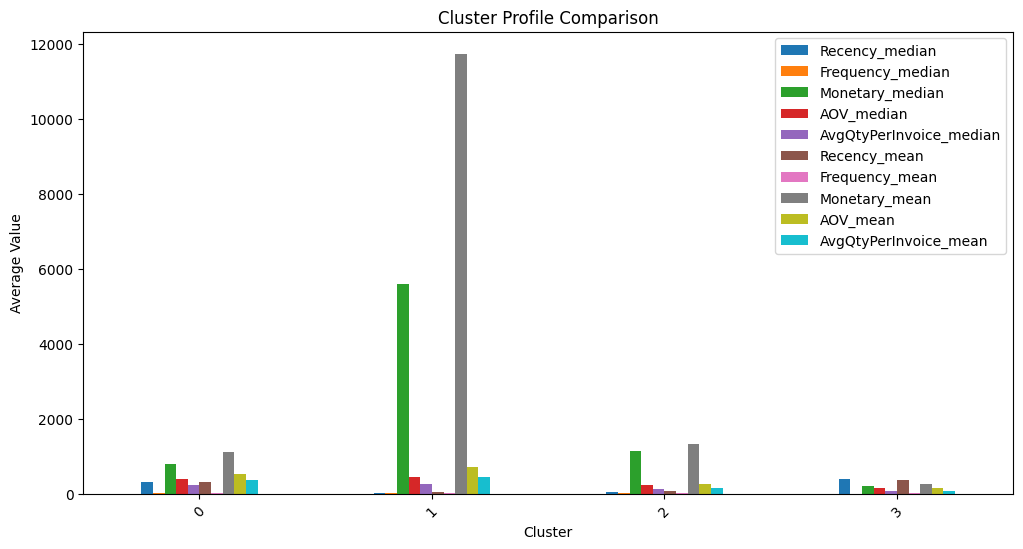

In [ ]:
# Bar Chart Comparison
cluster_profile.drop(['Customer_Count', 'Customer_%'], axis=1) \
    .plot(kind='bar', figsize=(12,6))

plt.title("Cluster Profile Comparison")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.show()

### Observation:
Cluster 3 shows the strongest performance: highest Monetary, Frequency, AOV, and Avg Quantity with low Recency → most valuable and active customers.

Cluster 1 has good Monetary and moderate Frequency with relatively low Recency → loyal but not top-tier.

Cluster 2 shows moderate Monetary but higher Recency and lower Frequency → slowing down customers.

Cluster 0 has the highest Recency and lowest Frequency and Monetary → inactive or at-risk customers.

## 6.4 Boxplots for Behavioral Distribution

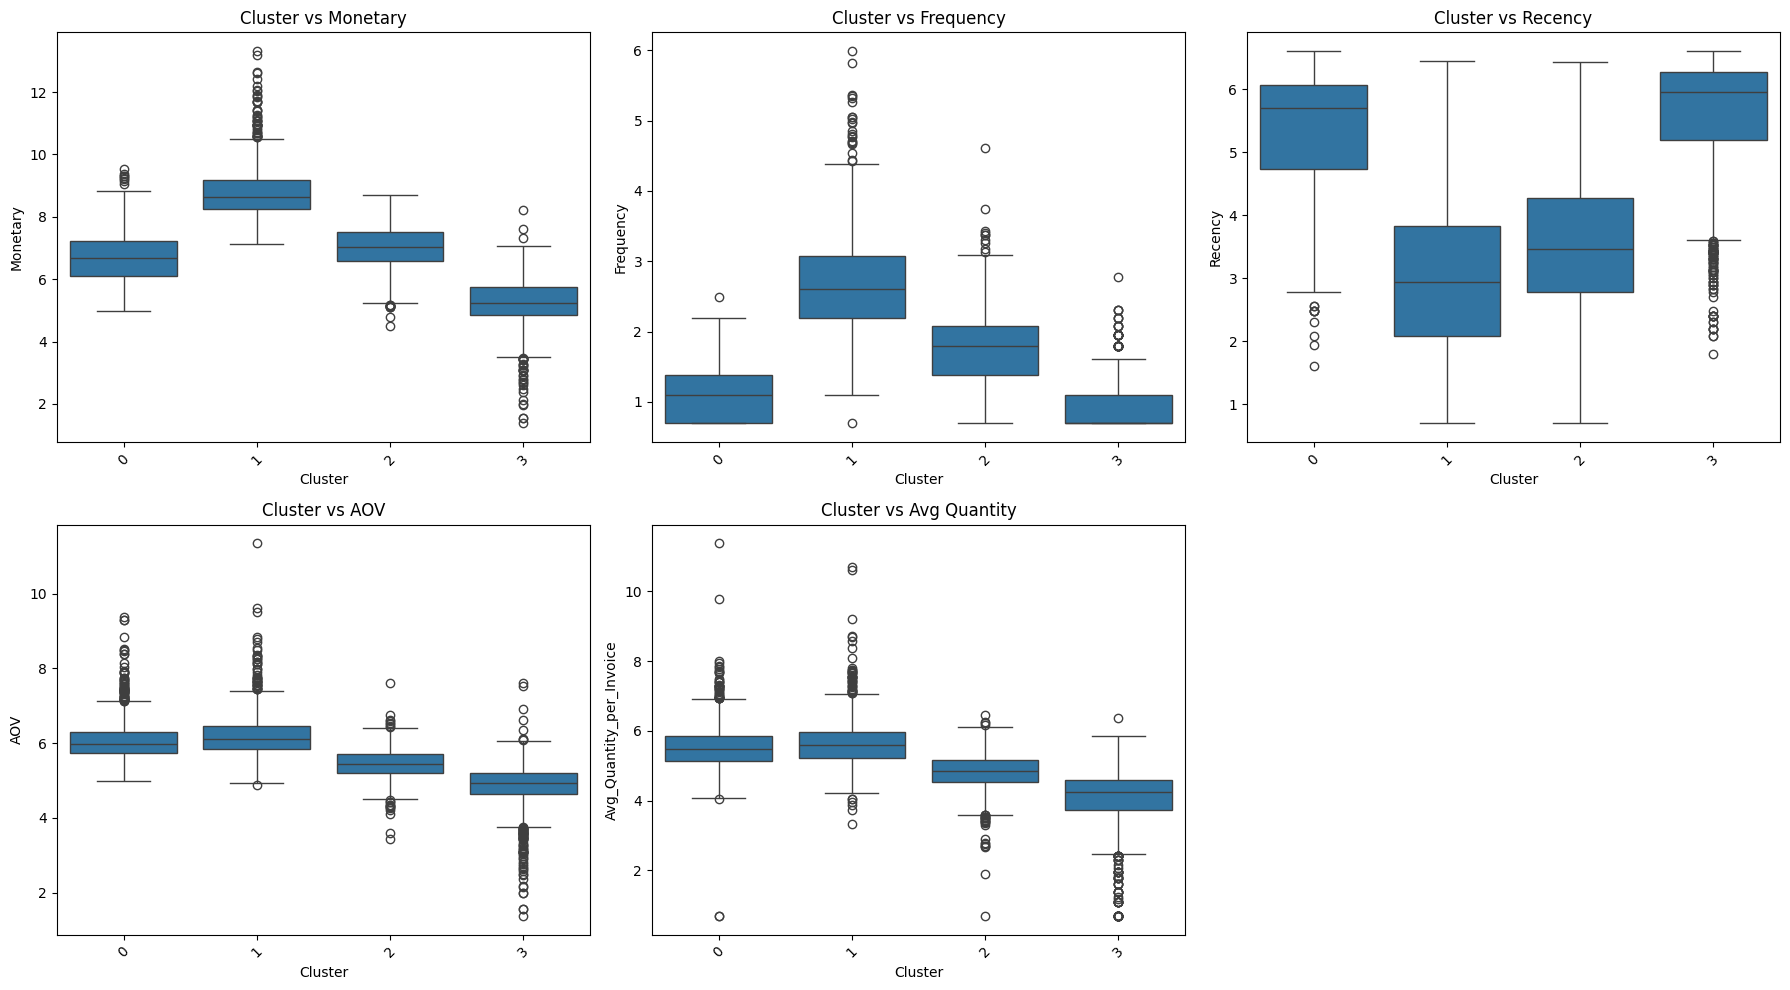

In [ ]:
# Box Plot Comparison

plt.figure(figsize=(18,10))

plt.subplot(2,3,1)
sns.boxplot(x='Cluster', y='Monetary', data=filtered) # Changed 'Segment' to 'Cluster'
plt.xticks(rotation=45)
plt.title('Cluster vs Monetary')

plt.subplot(2,3,2)
sns.boxplot(x='Cluster', y='Frequency', data=filtered) # Changed 'Segment' to 'Cluster'
plt.xticks(rotation=45)
plt.title('Cluster vs Frequency')

plt.subplot(2,3,3)
sns.boxplot(x='Cluster', y='Recency', data=filtered) # Changed 'Segment' to 'Cluster'
plt.xticks(rotation=45)
plt.title('Cluster vs Recency')

plt.subplot(2,3,4)
sns.boxplot(x='Cluster', y='AOV', data=filtered) # Changed 'Segment' to 'Cluster'
plt.xticks(rotation=45)
plt.title('Cluster vs AOV')

plt.subplot(2,3,5)
sns.boxplot(x='Cluster', y='Avg_Quantity_per_Invoice', data=filtered) # Changed 'Segment' to 'Cluster'
plt.xticks(rotation=45)
plt.title('Cluster vs Avg Quantity')

plt.tight_layout()
plt.show()

### Observation:
1️⃣ Monetary

Bulk Buyers have the highest spending.

Followed by At Risk Customers, then Regular Customers.

VIP Customers show the lowest monetary value.

2️⃣ Frequency

Bulk Buyers purchase most frequently.

At Risk Customers have moderate frequency.

Regular and VIP Customers have low purchase frequency.

3️⃣ Recency (lower = more recent purchase)

Bulk Buyers have the lowest recency → most recent buyers.

At Risk Customers are slightly less recent.

Regular and especially VIP Customers have high recency → longer time since last purchase.

4️⃣ AOV (Average Order Value)

Bulk Buyers have the highest AOV.

At Risk and Regular Customers are similar and moderate.

VIP Customers have the lowest AOV.

5️⃣ Average Quantity per Invoice

Bulk Buyers purchase the highest quantity per invoice.

At Risk and Regular Customers are moderate.

VIP Customers buy the least quantity.

## 6.5 PCA Clustering

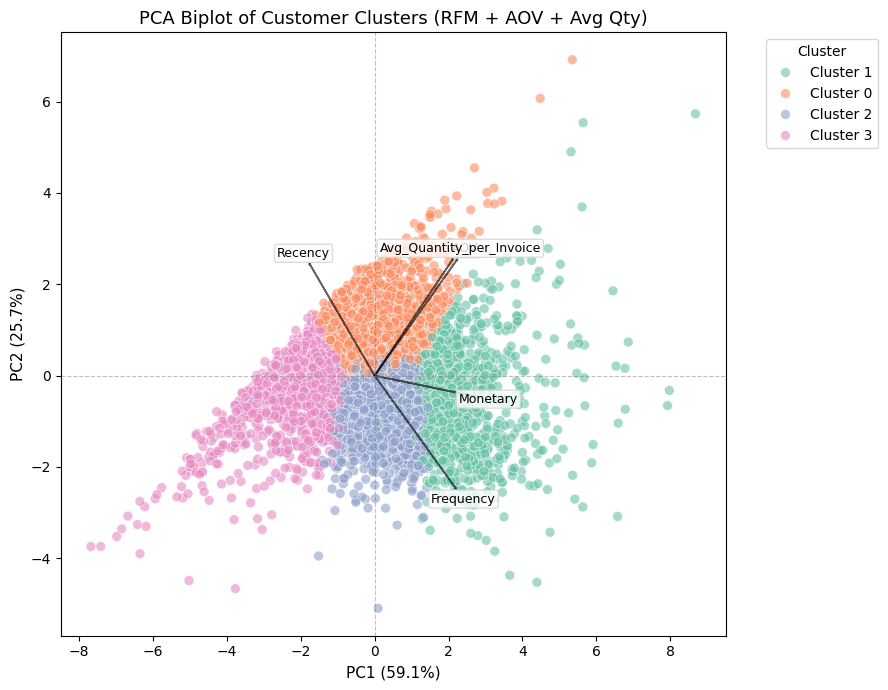


📊 PCA Summary:
PC1 explains: 59.1% of variance
PC2 explains: 25.7% of variance
Total explained: 84.8%


In [ ]:
# -----------------------------
# Choose the feature columns
# -----------------------------
all_metrics = ['Recency', 'Frequency', 'Monetary', 'AOV', 'Avg_Quantity_per_Invoice']

# -----------------------------
# 1) Build the PCA input matrix
#    Use filtered_log (log-space) OR filtered (original)
#    Here we use filtered_log as you intended.
# -----------------------------
X = filtered_log[all_metrics].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 2) Run PCA (NO random_state)
# -----------------------------
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

# -----------------------------
# 3) Build a plotting DF
#    IMPORTANT: merge cluster labels by customer_id
#    so row order cannot break.
# -----------------------------
plot_df = filtered[['customer_id', 'Cluster']].copy()

# If you want segment names, create them here
plot_df['Segment'] = 'Cluster ' + plot_df['Cluster'].astype(str)

plot_df['PC1'] = pca_components[:, 0]
plot_df['PC2'] = pca_components[:, 1]

# -----------------------------
# 4) Loadings (arrows)
# -----------------------------
loadings = pd.DataFrame(
    pca.components_.T,
    index=all_metrics,
    columns=["PC1", "PC2"]
)

# -----------------------------
# 5) Plot
# -----------------------------
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Segment",          # <--- guaranteed to exist now
    palette="Set2",
    alpha=0.6,
    s=50
)

plt.axhline(0, linestyle="--", linewidth=0.8, color='gray', alpha=0.5)
plt.axvline(0, linestyle="--", linewidth=0.8, color='gray', alpha=0.5)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
plt.title("PCA Biplot of Customer Clusters (RFM + AOV + Avg Qty)", fontsize=13)

plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

# Draw PCA loading vectors
scale = 5
for var in loadings.index:
    x_loading = loadings.loc[var, "PC1"]
    y_loading = loadings.loc[var, "PC2"]

    plt.arrow(
        0, 0,
        x_loading * scale,
        y_loading * scale,
        head_width=0.05,
        head_length=0.03,
        fc='black',
        ec='black',
        alpha=0.6,
        linewidth=1.2
    )

    plt.text(
        x_loading * scale * 1.1,
        y_loading * scale * 1.1,
        var,
        fontsize=9,
        ha='center',
        va='center',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor='lightgray')
    )

plt.tight_layout()
plt.show()

print("\n📊 PCA Summary:")
print("=" * 40)
print(f"PC1 explains: {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]*100:.1f}% of variance")
print(f"Total explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

## 6.5 Heatmap

In [ ]:
# =====================================
# COMPLETE HEATMAP WITH ALL METRICS (CORRECT)
# - Safe cluster assignment (merge by customer_id)
# - Monetary contribution based on SUM (true revenue share)
# - Medians for the typical customer profile
# =====================================

# Original values (non-log)
original_values = rfm[['customer_id', 'Recency', 'Frequency', 'Monetary', 'AOV', 'Avg_Quantity_per_Invoice']].copy()

# Safe cluster labels by customer_id
cluster_map = filtered[['customer_id', 'Cluster']].copy()
original_values = original_values.merge(cluster_map, on='customer_id', how='inner')

# Summary: medians for profile + sum for revenue share
cluster_summary_full = original_values.groupby('Cluster').agg(
    n_member=('customer_id', 'nunique'),
    recency=('Recency', 'median'),
    frequency=('Frequency', 'median'),
    monetary=('Monetary', 'median'),
    monetary_sum=('Monetary', 'sum'),
    aov=('AOV', 'median'),
    avg_quantity=('Avg_Quantity_per_Invoice', 'median')
).reset_index()

total_customers = cluster_summary_full['n_member'].sum()
total_revenue = cluster_summary_full['monetary_sum'].sum()

cluster_summary_full['percent_member'] = cluster_summary_full['n_member'] / total_customers
cluster_summary_full['monetary_contribution'] = cluster_summary_full['monetary_sum'] / total_revenue

cluster_summary_full['segment'] = 'Cluster ' + cluster_summary_full['Cluster'].astype(str)

cluster_summary_full = cluster_summary_full[[
    'Cluster', 'segment', 'n_member', 'percent_member',
    'recency', 'frequency', 'monetary', 'monetary_contribution',
    'aov', 'avg_quantity'
]]

cluster_summary_full.sort_values('Cluster', inplace=True)

styled_complete = (
    cluster_summary_full.style
    .hide(axis='index')
    .format({
        'n_member': '{:,.0f}',
        'percent_member': '{:.1%}',
        'recency': '{:.0f} days',
        'frequency': '{:.1f} purchases',
        'monetary': '${:,.0f}',
        'monetary_contribution': '{:.1%}',
        'aov': '${:.2f}',
        'avg_quantity': '{:.1f} items'
    })
    .background_gradient(cmap='Reds', subset=['recency'])
    .background_gradient(cmap='Greens', subset=['frequency', 'monetary', 'monetary_contribution'])
    .background_gradient(cmap='Blues', subset=['aov', 'avg_quantity'])
    .background_gradient(cmap='Purples', subset=['n_member', 'percent_member'])
    .set_caption("📊 CUSTOMER SEGMENTS - COMPLETE PROFILE ANALYSIS")
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '18px'), ('font-weight', 'bold'), ('color', 'white'),
                   ('text-align', 'center'), ('background-color', '#1a1a1a'),
                   ('padding', '12px'), ('border-radius', '5px')]},
        {'selector': 'th',
         'props': [('font-size', '12px'), ('text-align', 'center'), ('padding', '8px'),
                   ('font-weight', 'bold')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '6px')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#ffff99')]}
    ])
    .set_properties(**{'border': '1px solid #ddd'})
)

styled_complete

Cluster,segment,n_member,percent_member,recency,frequency,monetary,monetary_contribution,aov,avg_quantity
0,Cluster 0,"1,763",30.0%,299 days,2.0 purchases,$798,11.0%,$393.26,239.0 items
1,Cluster 1,"1,142",19.4%,18 days,12.5 purchases,"$5,599",75.5%,$447.58,267.3 items
2,Cluster 2,"1,552",26.4%,31 days,5.0 purchases,"$1,131",11.6%,$231.23,126.4 items
3,Cluster 3,"1,421",24.2%,383 days,1.0 purchases,$189,1.9%,$137.37,68.0 items


In [ ]:
# --- Build the full summary exactly like you already do ---
original_values = rfm[['customer_id', 'Recency', 'Frequency', 'Monetary', 'AOV', 'Avg_Quantity_per_Invoice']].copy()

cluster_map = filtered[['customer_id', 'Cluster']].copy()
original_values = original_values.merge(cluster_map, on='customer_id', how='inner')

cluster_summary_full = original_values.groupby('Cluster').agg(
    n_member=('customer_id', 'nunique'),
    recency=('Recency', 'median'),
    frequency=('Frequency', 'median'),
    monetary=('Monetary', 'median'),
    monetary_sum=('Monetary', 'sum'),
    aov=('AOV', 'median'),
    avg_quantity=('Avg_Quantity_per_Invoice', 'median')
).reset_index()

total_customers = cluster_summary_full['n_member'].sum()
total_revenue = cluster_summary_full['monetary_sum'].sum()

cluster_summary_full['percent_member'] = cluster_summary_full['n_member'] / total_customers
cluster_summary_full['monetary_contribution'] = cluster_summary_full['monetary_sum'] / total_revenue
cluster_summary_full['segment'] = 'Cluster ' + cluster_summary_full['Cluster'].astype(str)

cluster_summary_full = cluster_summary_full[[
    'Cluster', 'segment', 'n_member', 'percent_member',
    'recency', 'frequency', 'monetary', 'monetary_contribution',
    'aov', 'avg_quantity'
]].sort_values('Cluster')

# --- Styling function (reuse your exact styles) ---
def style_heatmap(df_one):
    return (
        df_one.style
        .hide(axis='index')
        .format({
            'n_member': '{:,.0f}',
            'percent_member': '{:.1%}',
            'recency': '{:.0f} days',
            'frequency': '{:.1f} purchases',
            'monetary': '${:,.0f}',
            'monetary_contribution': '{:.1%}',
            'aov': '${:.2f}',
            'avg_quantity': '{:.1f} items'
        })
        .background_gradient(cmap='Reds', subset=['recency'])
        .background_gradient(cmap='Greens', subset=['frequency', 'monetary', 'monetary_contribution'])
        .background_gradient(cmap='Blues', subset=['aov', 'avg_quantity'])
        .background_gradient(cmap='Purples', subset=['n_member', 'percent_member'])
        .set_caption(f"📊 CUSTOMER SEGMENT PROFILE — {df_one['segment'].iloc[0]}")
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '18px'), ('font-weight', 'bold'), ('color', 'white'),
                       ('text-align', 'center'), ('background-color', '#1a1a1a'),
                       ('padding', '12px'), ('border-radius', '5px')]},
            {'selector': 'th',
             'props': [('font-size', '12px'), ('text-align', 'center'), ('padding', '8px'),
                       ('font-weight', 'bold')]},
            {'selector': 'td',
             'props': [('text-align', 'center'), ('padding', '6px')]},
            {'selector': 'tr:hover',
             'props': [('background-color', '#ffff99')]}
        ])
        .set_properties(**{'border': '1px solid #ddd'})
    )

# --- Create one output per cluster (Jupyter will display each table) ---
for cl in sorted(cluster_summary_full['Cluster'].unique()):
    df_one = cluster_summary_full[cluster_summary_full['Cluster'] == cl]
    display(style_heatmap(df_one))

Cluster,segment,n_member,percent_member,recency,frequency,monetary,monetary_contribution,aov,avg_quantity
0,Cluster 0,"1,763",30.0%,299 days,2.0 purchases,$798,11.0%,$393.26,239.0 items


Cluster,segment,n_member,percent_member,recency,frequency,monetary,monetary_contribution,aov,avg_quantity
1,Cluster 1,"1,142",19.4%,18 days,12.5 purchases,"$5,599",75.5%,$447.58,267.3 items


Cluster,segment,n_member,percent_member,recency,frequency,monetary,monetary_contribution,aov,avg_quantity
2,Cluster 2,"1,552",26.4%,31 days,5.0 purchases,"$1,131",11.6%,$231.23,126.4 items


Cluster,segment,n_member,percent_member,recency,frequency,monetary,monetary_contribution,aov,avg_quantity
3,Cluster 3,"1,421",24.2%,383 days,1.0 purchases,$189,1.9%,$137.37,68.0 items


#